## Importando bibliotecas

In [22]:
import pandas as pd
import scipy.stats as stats
import datetime as dt
import numpy as np
import math as mth
import matplotlib.pyplot as plt
import os

## Lendo os dados

In [9]:
hypotheses_path = os.path.join(os.getcwd(), '..', 'data', 'hypotheses_us.csv')
hypotheses = pd.read_csv(hypotheses_path, sep=';')

orders_path = os.path.join(os.getcwd(), '..', 'data', 'orders_us.csv')
orders = pd.read_csv(orders_path)

visits_path = os.path.join(os.getcwd(), '..', 'data', 'visits_us.csv')
visits = pd.read_csv(visits_path)

## Explorando cada dataset

In [10]:
print('HYPOTHESES:')
print()
print(hypotheses.info())
print(hypotheses.head(10))

HYPOTHESES:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Hypothesis  9 non-null      object
 1   Reach       9 non-null      int64 
 2   Impact      9 non-null      int64 
 3   Confidence  9 non-null      int64 
 4   Effort      9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 492.0+ bytes
None
                                          Hypothesis  Reach  Impact  \
0  Add two new channels for attracting traffic. T...      3      10   
1  Launch your own delivery service. This will sh...      2       5   
2  Add product recommendation blocks to the store...      8       3   
3  Change the category structure. This will incre...      8       3   
4  Change the background color on the main page. ...      3       1   
5  Add a customer review page. This will increase...      3       2   
6  Show banners with current offers and sales on .

In [11]:
print('ORDERS:')
print()
print(orders.info())
print(orders.head())

ORDERS:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   transactionId  1197 non-null   int64  
 1   visitorId      1197 non-null   int64  
 2   date           1197 non-null   object 
 3   revenue        1197 non-null   float64
 4   group          1197 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 46.9+ KB
None
   transactionId   visitorId        date  revenue group
0     3667963787  3312258926  2019-08-15     30.4     B
1     2804400009  3642806036  2019-08-15     15.2     B
2     2961555356  4069496402  2019-08-15     10.2     A
3     3797467345  1196621759  2019-08-15    155.1     B
4     2282983706  2322279887  2019-08-15     40.5     B


In [12]:
print('Quantidade total de visitantes:', orders['visitorId'].nunique())
print()
orders['date'] = pd.to_datetime(orders['date'])
print(orders.info())

Quantidade total de visitantes: 1031

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   transactionId  1197 non-null   int64         
 1   visitorId      1197 non-null   int64         
 2   date           1197 non-null   datetime64[ns]
 3   revenue        1197 non-null   float64       
 4   group          1197 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 46.9+ KB
None


In [13]:
# Verificando se há algum visitante que possa estar nos dois grupos
visitors_per_group = orders.groupby('visitorId')['group'].nunique()
visitors_from_both_groups = visitors_per_group[visitors_per_group > 1]

print(f'Visitantes em ambos os grupos: {len(visitors_from_both_groups)}')

Visitantes em ambos os grupos: 58


In [14]:
print('VISITS:')
print()
print(visits.info())
print(visits.head(10))

VISITS:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    62 non-null     object
 1   group   62 non-null     object
 2   visits  62 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.6+ KB
None
         date group  visits
0  2019-08-01     A     719
1  2019-08-02     A     619
2  2019-08-03     A     507
3  2019-08-04     A     717
4  2019-08-05     A     756
5  2019-08-06     A     667
6  2019-08-07     A     644
7  2019-08-08     A     610
8  2019-08-09     A     617
9  2019-08-10     A     406


In [15]:
print('Grupos únicos:', orders['group'].unique())
print()
visits['date'] = pd.to_datetime(visits['date'])
print(visits.info())

Grupos únicos: ['B' 'A']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    62 non-null     datetime64[ns]
 1   group   62 non-null     object        
 2   visits  62 non-null     int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.6+ KB
None


## Priorizando hipóteses

In [18]:
# Aplicando o framework ICE
hypotheses['ICE'] = hypotheses['Impact'] * hypotheses['Confidence'] / hypotheses['Effort']
hypotheses = hypotheses.sort_values(by='ICE', ascending=False)
print(hypotheses[['Hypothesis', 'ICE']])

                                          Hypothesis        ICE
8  Launch a promotion that gives users discounts ...  16.200000
0  Add two new channels for attracting traffic. T...  13.333333
7  Add a subscription form to all the main pages....  11.200000
6  Show banners with current offers and sales on ...   8.000000
2  Add product recommendation blocks to the store...   7.000000
1  Launch your own delivery service. This will sh...   2.000000
5  Add a customer review page. This will increase...   1.333333
3  Change the category structure. This will incre...   1.125000
4  Change the background color on the main page. ...   1.000000


In [19]:
# Aplicando o framework RICE
hypotheses['RICE'] = hypotheses['Reach'] * hypotheses['Impact'] * hypotheses['Confidence'] / hypotheses['Effort']
hypotheses = hypotheses.sort_values(by='RICE', ascending=False)
print(hypotheses[['Hypothesis', 'ICE', 'RICE']])

                                          Hypothesis        ICE   RICE
7  Add a subscription form to all the main pages....  11.200000  112.0
2  Add product recommendation blocks to the store...   7.000000   56.0
0  Add two new channels for attracting traffic. T...  13.333333   40.0
6  Show banners with current offers and sales on ...   8.000000   40.0
8  Launch a promotion that gives users discounts ...  16.200000   16.2
3  Change the category structure. This will incre...   1.125000    9.0
1  Launch your own delivery service. This will sh...   2.000000    4.0
5  Add a customer review page. This will increase...   1.333333    4.0
4  Change the background color on the main page. ...   1.000000    3.0


Explicação prévia:

- Cada hipótese recebe uma pontuação ICE que equilibra três fatores:

   - Impact — quão grande será o impacto se funcionar

   - Confidence — quão confiante você está de que vai funcionar

   - Effort — quanto esforço/recurso é necessário para implementar

A hipótese no topo é a de maior prioridade — maior impacto esperado, maior confiança e menor esforço relativo.

Comparar ICE vs RICE é útil: hipóteses que sobem no ranking RICE têm alto alcance; as que caem tinham boa pontuação ICE, mas atingem poucos usuários. Isso ajuda a priorizar com mais precisão.

Logo, o RICE é mais confiável para priorização porque o ICE pode enganar — uma iniciativa pode parecer ótima por ter impacto e confiança altos, mas se atinge poucos usuários, o retorno real para o negócio é pequeno. O RICE corrige isso multiplicando pelo alcance antes de comparar as hipóteses.

In [20]:
# Comparando a mudança de posição no ranking ICE vs RICE
ice_order = hypotheses.sort_values('ICE', ascending=False).reset_index(drop=True)
ice_order.index += 1
ice_order['ICE_rank'] = ice_order.index

rice_order = hypotheses.sort_values('RICE', ascending=False).reset_index(drop=True)
rice_order.index += 1
rice_order['RICE_rank'] = rice_order.index

comparison = pd.merge(
    ice_order[['Hypothesis', 'Reach', 'ICE', 'ICE_rank']],
    rice_order[['Hypothesis', 'RICE', 'RICE_rank']],
    on='Hypothesis'
)
comparison['Variação'] = comparison['ICE_rank'] - comparison['RICE_rank']
comparison['Movimento'] = comparison['Variação'].apply(
    lambda x: f'↑ {abs(x)} posições' if x > 0 else (f'↓ {abs(x)} posições' if x < 0 else 'Sem mudança')
)

comparison = comparison.sort_values('RICE_rank')
print(comparison[['Hypothesis', 'Reach', 'ICE_rank', 'RICE_rank', 'Variação', 'Movimento']].to_string(index=False))


                                                                                                            Hypothesis  Reach  ICE_rank  RICE_rank  Variação    Movimento
                              Add a subscription form to all the main pages. This will help you compile a mailing list     10         3          1         2 ↑ 2 posições
        Add product recommendation blocks to the store's site. This will increase conversion and average purchase size      8         5          2         3 ↑ 3 posições
                                           Add two new channels for attracting traffic. This will bring 30% more users      3         2          3        -1 ↓ 1 posições
                               Show banners with current offers and sales on the main page. This will boost conversion      5         4          4         0  Sem mudança
                                                      Launch a promotion that gives users discounts on their birthdays      1         1          5    

### Analisando como a priorização muda do ICE para o RICE:

O **RICE** adiciona o fator **Reach** (alcance) ao ICE, multiplicando a pontuação pelo número de usuários/pedidos que a hipótese vai atingir.

**Principais mudanças observadas:**

| Hipótese | Reach | ICE rank | RICE rank | Movimento |
|---|---|---|---|---|
| Add a subscription form... | **10** | 3º | **1º** | ↑ 2 posições |
| Add product recommendation blocks... | **8** | 5º | **2º** | ↑ 3 posições |
| Launch a promotion (birthday discounts) | **1** | 1º | **5º** | ↓ 4 posições |
| Change the category structure... | **8** | 8º | **6º** | ↑ 2 posições |

**Explicação das mudanças:**

- **"Launch a promotion (birthday discounts)"** era o 1º no ICE por ter Impact=9 e Confidence=9. Porém o Reach é **apenas 1** — a promoção atinge um número muito pequeno de usuários. No RICE, essa limitação fica evidente e ela cai para o 5º lugar.

- **"Add a subscription form..."** e **"Add product recommendation blocks..."** subiram significativamente porque têm Reach alto (**10** e **8**). No ICE elas pareciam medianas, mas no RICE fica claro que impactam uma base grande de usuários, tornando-as mais valiosas para o negócio.

- **Conclusão:** O RICE é mais completo que o ICE porque evita priorizar iniciativas que têm ótimos índices de impacto e confiança, mas que só beneficiam poucos usuários. Ele força a considerar a escala do benefício.


## Análise de teste A/B

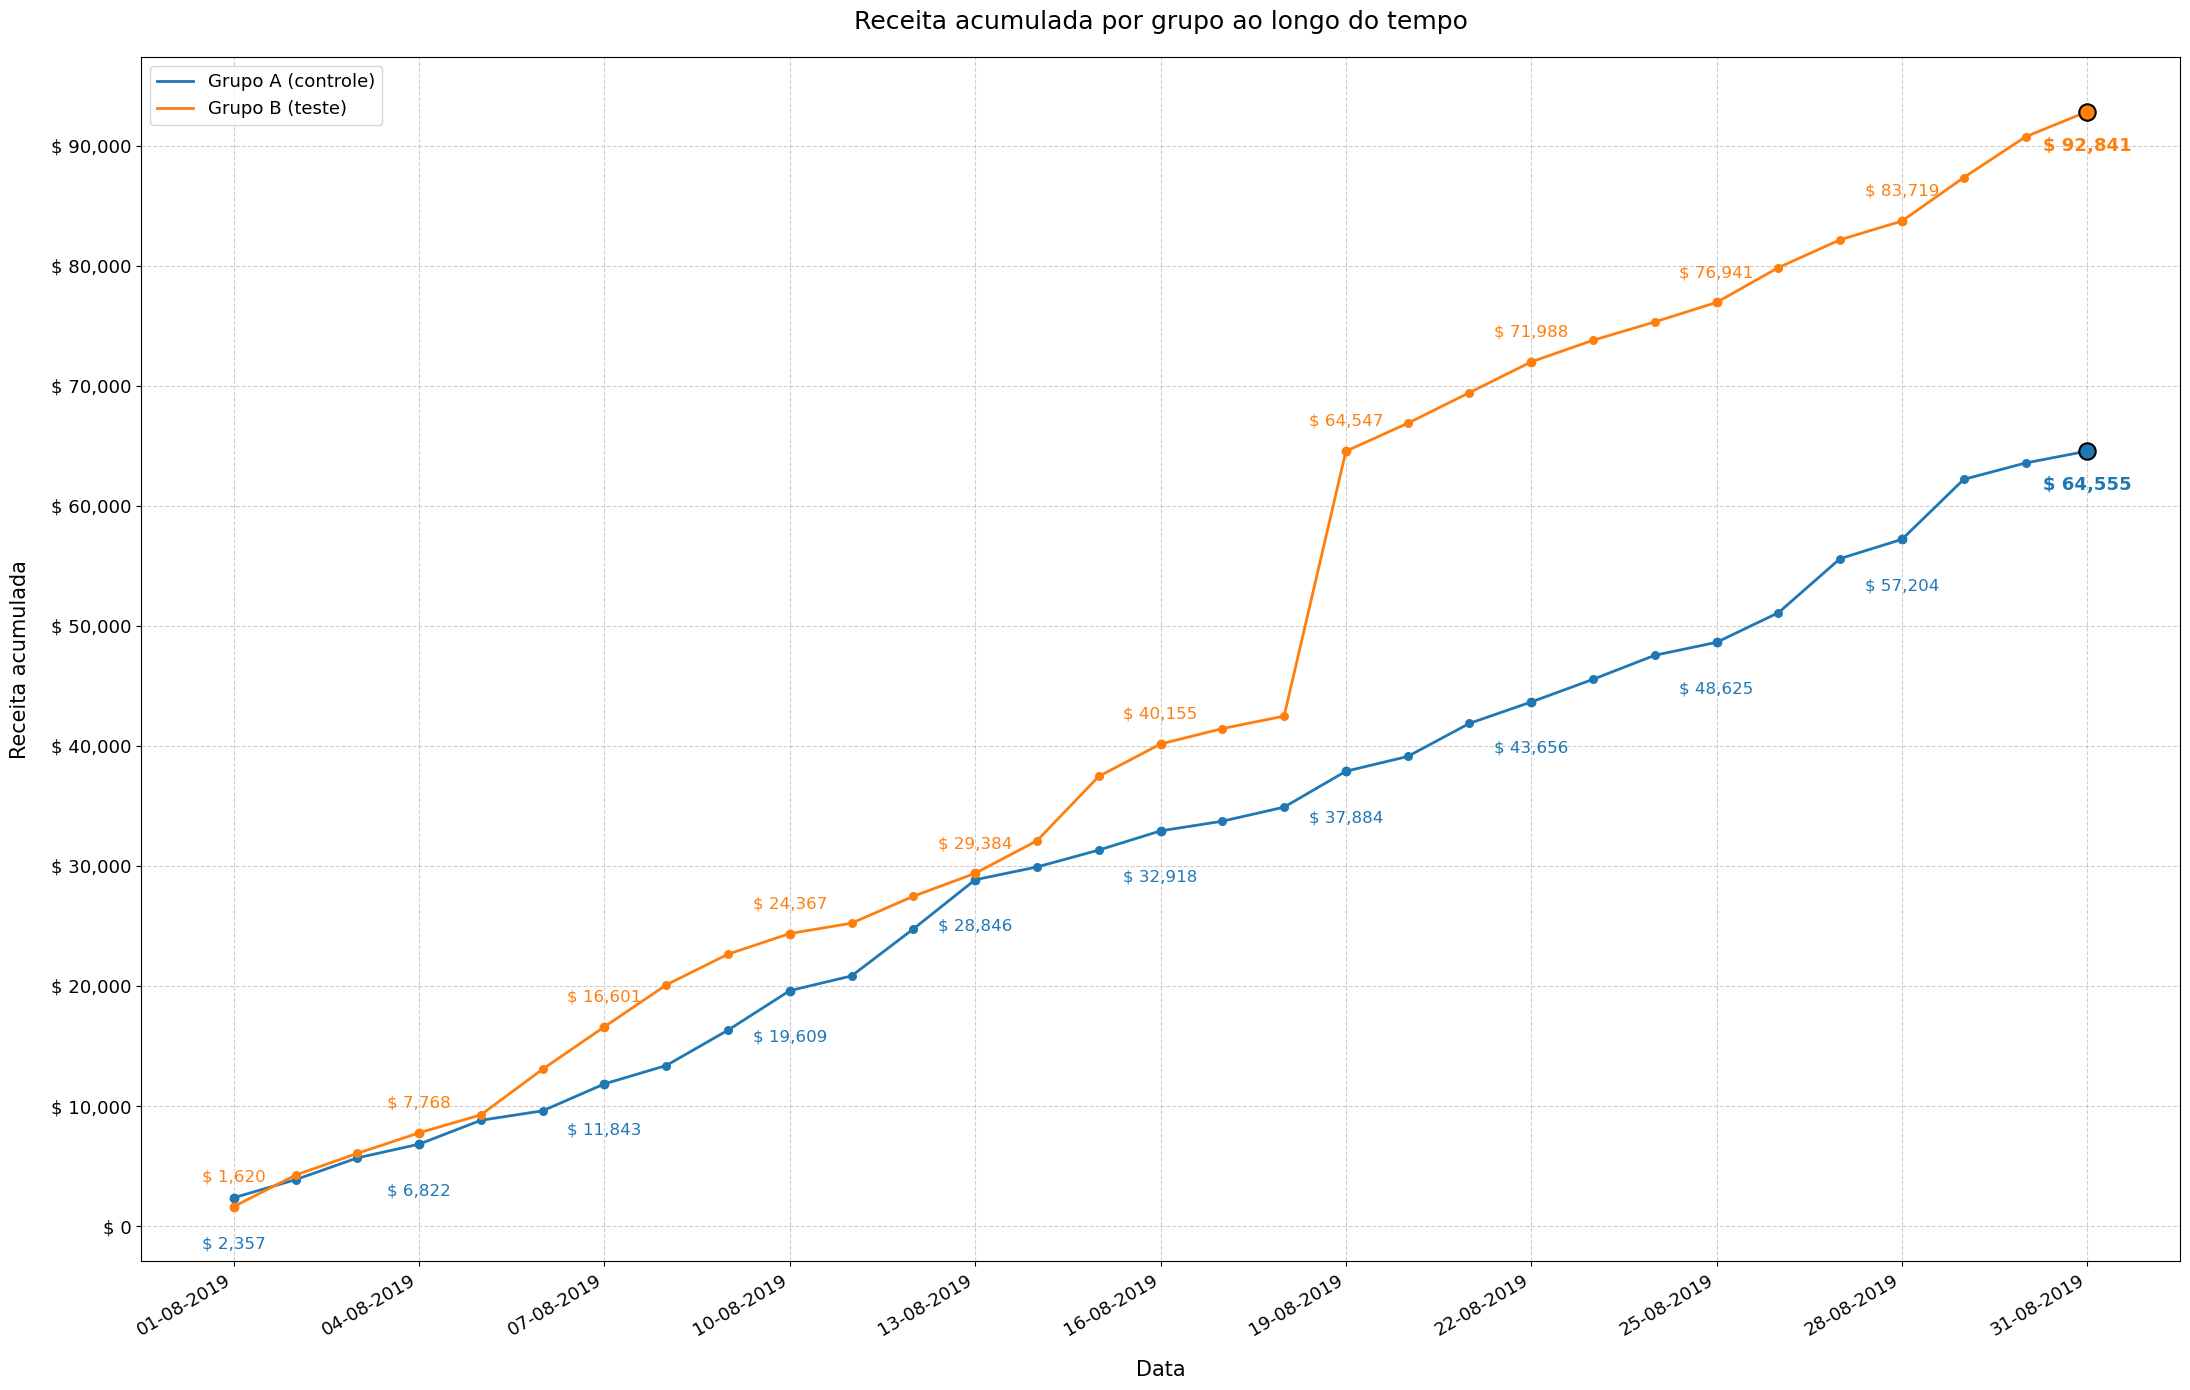

In [38]:
import matplotlib.ticker as ticker
import matplotlib.dates as mdates

# Receita acumulada por grupo ao longo do tempo
cumulative_revenue = (
    orders.groupby(['date', 'group'])['revenue']
    .sum()
    .unstack('group')
    .fillna(0)
    .cumsum()
)

# Datas de destaque
all_dates = cumulative_revenue.index
highlight_dates = all_dates[::3]
if all_dates[-1] not in highlight_dates:
    highlight_dates = highlight_dates.append(pd.DatetimeIndex([all_dates[-1]]))

FONT = 13  # tamanho base da fonte

fig, ax = plt.subplots(figsize=(22, 14))

configs = [
    ('A', '#1f77b4', 'Grupo A (controle)', -28, 'top'),    # labels abaixo da linha
    ('B', '#ff7f0e', 'Grupo B (teste)',     +16, 'bottom'), # labels acima da linha
]

for group, color, lbl, y_offset, va in configs:
    ax.plot(cumulative_revenue.index, cumulative_revenue[group],
            color=color, label=lbl, linewidth=2)
    ax.scatter(cumulative_revenue.index, cumulative_revenue[group],
               color=color, s=30, zorder=3)

    for d in highlight_dates:
        val = cumulative_revenue.loc[d, group]
        is_last  = (d == all_dates[-1])
        is_first = (d == all_dates[0])

        ax.scatter(d, val, color=color,
                   s=140 if is_last else 50,
                   zorder=5,
                   edgecolors='black' if is_last else color,
                   linewidths=1.5 if is_last else 0)

        if is_last:
            # Ponto final
            ax.annotate(f'$ {val:,.0f}',
                        xy=(d, val),
                        xytext=(0, -18),
                        textcoords='offset points',
                        fontsize=FONT, fontweight='bold', color=color,
                        va='top', ha='center')
        elif is_first:
            # Primeiro ponto
            ax.annotate(f'$ {val:,.0f}',
                        xy=(d, val),
                        xytext=(0, y_offset),
                        textcoords='offset points',
                        fontsize=FONT - 1, color=color,
                        ha='center', va=va)
        else:
            ax.annotate(f'$ {val:,.0f}',
                        xy=(d, val),
                        xytext=(0, y_offset),
                        textcoords='offset points',
                        fontsize=FONT - 1, color=color,
                        ha='center', va=va)

# Eixo X
ax.set_xticks(highlight_dates)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))
plt.xticks(rotation=30, ha='right', fontsize=FONT)
plt.yticks(fontsize=FONT)

# Eixo Y
ax.yaxis.set_major_locator(ticker.MultipleLocator(10000))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'$ {x:,.0f}'))

ax.set_title('Receita acumulada por grupo ao longo do tempo', pad=20, fontsize=FONT + 5)
ax.set_xlabel('Data', labelpad=15, fontsize=FONT + 2)
ax.set_ylabel('Receita acumulada', labelpad=15, fontsize=FONT + 2)
ax.legend(fontsize=FONT)
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



### Conclusões — Receita acumulada por grupo

- **O Grupo B (teste) gerou mais receita acumulada** do que o Grupo A ao longo de todo o período, terminando em ~R$92.000 contra ~R$65.000 do Grupo A.

- **Até ~08/08**, os dois grupos andavam praticamente juntos, com diferença marginal.

- **A partir de ~08/09**, o Grupo B começa a se distanciar progressivamente — o que sugere que a mudança testada começa a surtir efeito com o acúmulo de dias.

- **Entre 08/17 e 08/19**, há um salto abrupto na receita do Grupo B (de ~42.000 para ~65.000 em dois dias). Isso é um sinal de alerta: pode indicar a presença de **outliers** — pedidos atípicos de valor muito alto que distorcem a receita acumulada. Antes de concluir que o Grupo B é superior, é necessário investigar se há anomalias nesses dados.

**Conjectura:** O Grupo B aparenta ter melhor desempenho em receita, mas o salto brusco a partir do dia 17/08 levanta suspeita de outliers. A análise dos próximos passos (pedidos por visitante, receita média por visitante) ajudará a confirmar ou refutar essa superioridade.


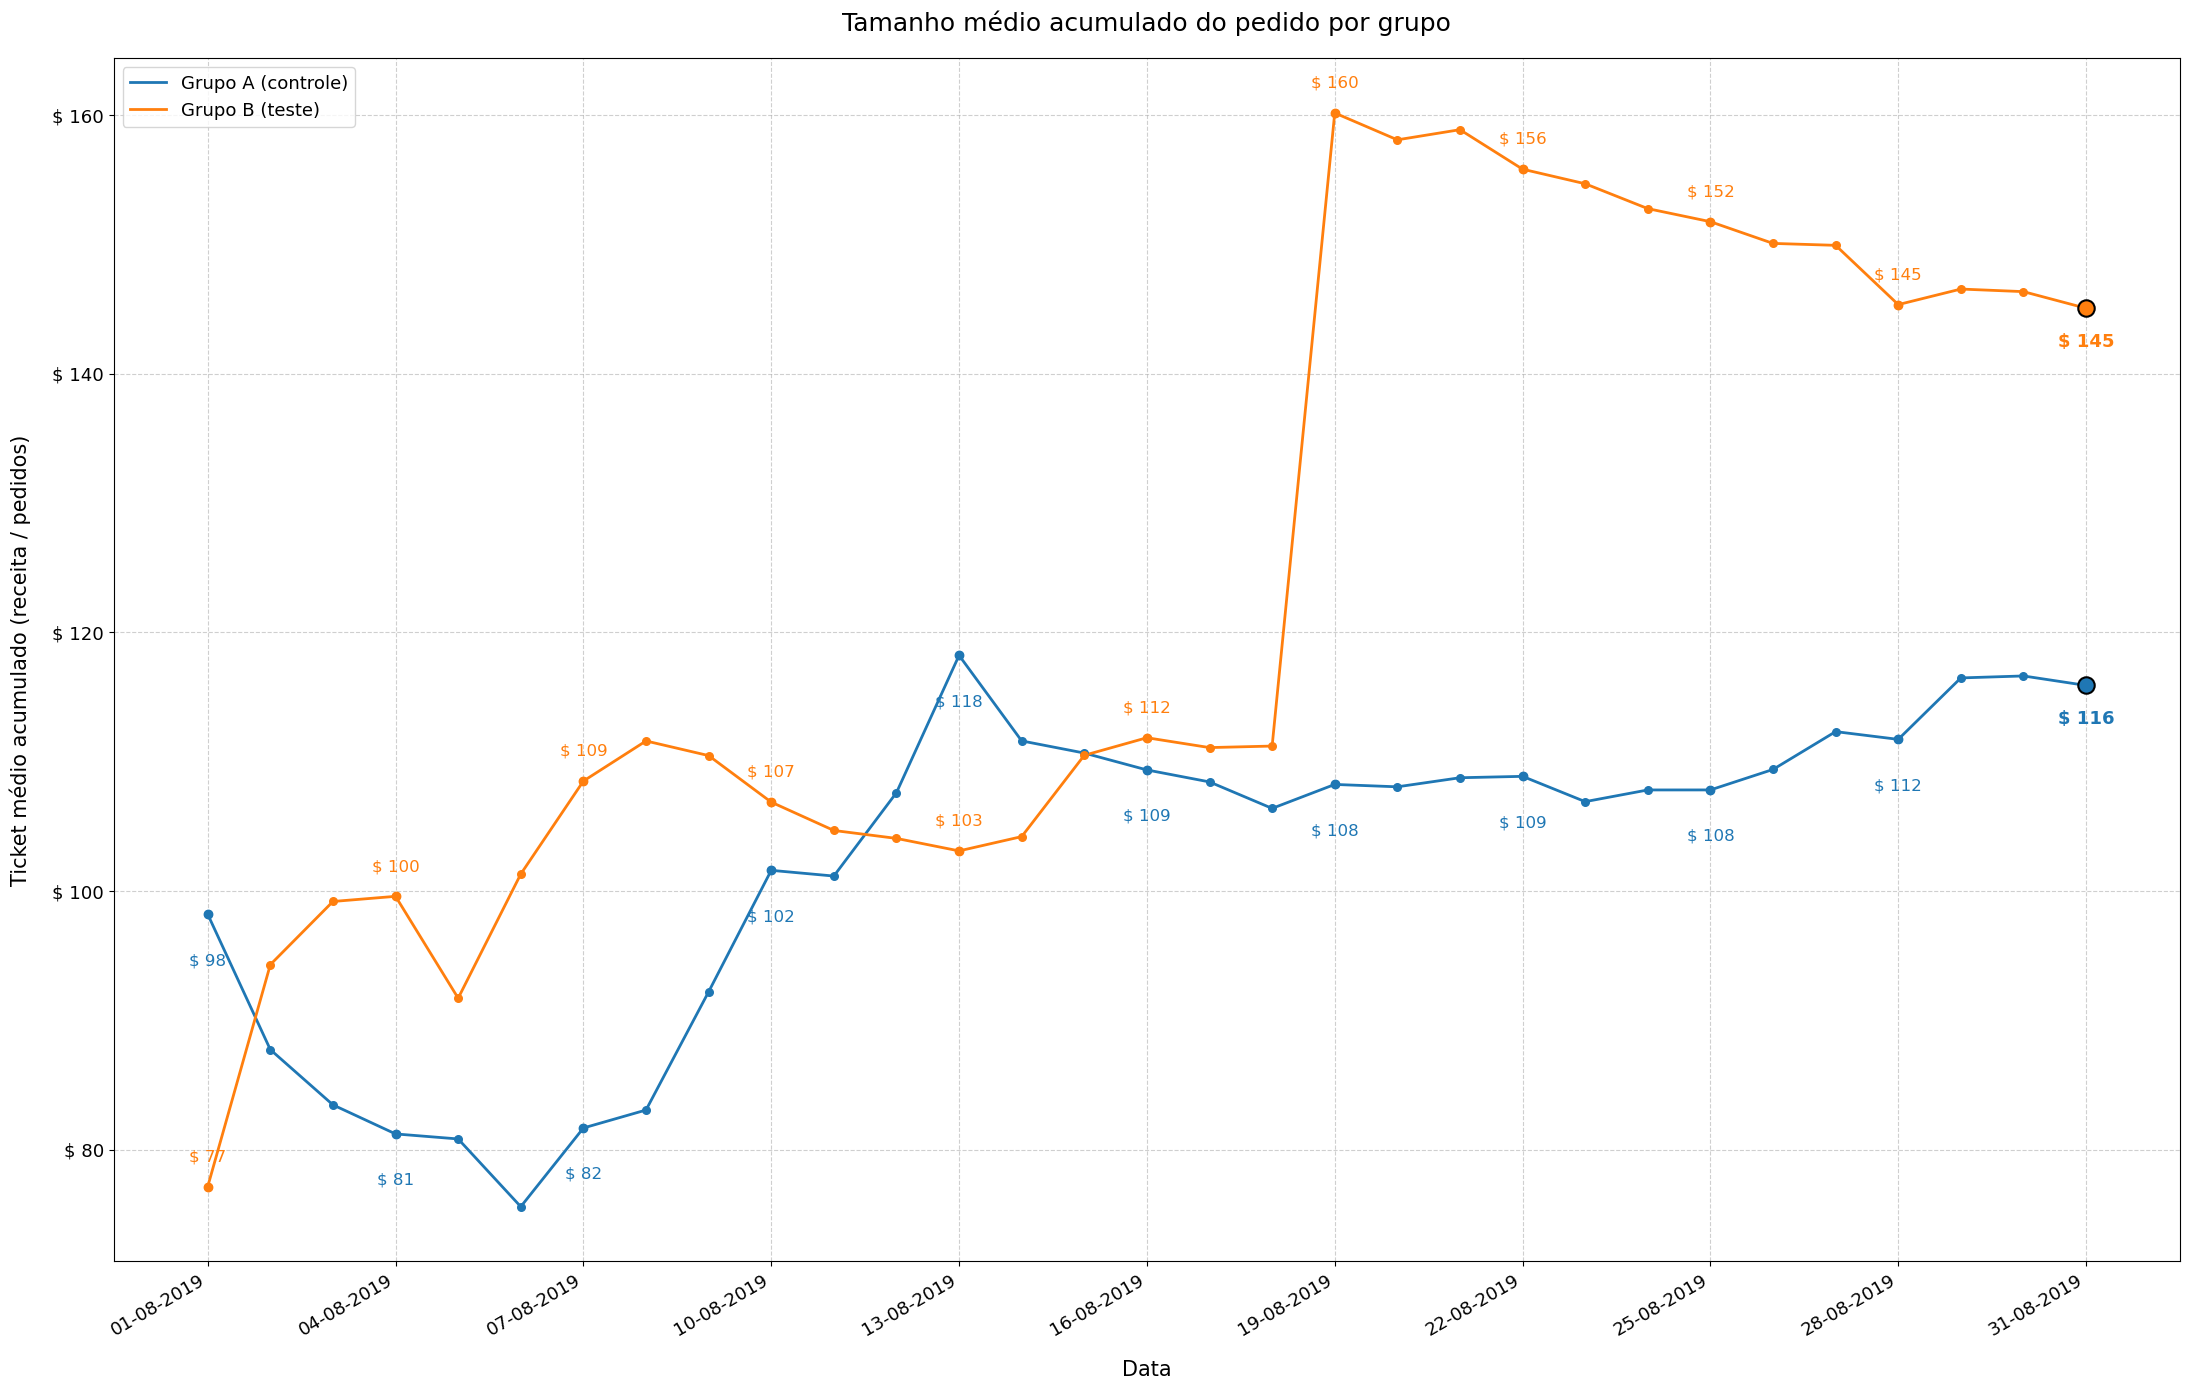

In [40]:
# Número de pedidos acumulados por grupo
cumulative_orders = (
    orders.groupby(['date', 'group'])['transactionId']
    .count()
    .unstack('group')
    .fillna(0)
    .cumsum()
)

# Tamanho médio acumulado do pedido = receita acumulada / nº de pedidos acumulados
cumulative_avg_order = cumulative_revenue / cumulative_orders

fig, ax = plt.subplots(figsize=(22, 14))

configs_avg = [
    ('A', '#1f77b4', 'Grupo A (controle)', -28, 'top'),
    ('B', '#ff7f0e', 'Grupo B (teste)',     +16, 'bottom'),
]

for group, color, lbl, y_offset, va in configs_avg:
    ax.plot(cumulative_avg_order.index, cumulative_avg_order[group],
            color=color, label=lbl, linewidth=2)
    ax.scatter(cumulative_avg_order.index, cumulative_avg_order[group],
               color=color, s=30, zorder=3)

    for d in highlight_dates:
        val = cumulative_avg_order.loc[d, group]
        is_last  = (d == all_dates[-1])
        is_first = (d == all_dates[0])

        ax.scatter(d, val, color=color,
                   s=140 if is_last else 50,
                   zorder=5,
                   edgecolors='black' if is_last else color,
                   linewidths=1.5 if is_last else 0)

        if is_last:
            ax.annotate(f'$ {val:,.0f}',
                        xy=(d, val),
                        xytext=(0, -18),
                        textcoords='offset points',
                        fontsize=FONT, fontweight='bold', color=color,
                        va='top', ha='center')
        elif is_first:
            ax.annotate(f'$ {val:,.0f}',
                        xy=(d, val),
                        xytext=(0, y_offset),
                        textcoords='offset points',
                        fontsize=FONT - 1, color=color,
                        ha='center', va=va)
        else:
            ax.annotate(f'$ {val:,.0f}',
                        xy=(d, val),
                        xytext=(0, y_offset),
                        textcoords='offset points',
                        fontsize=FONT - 1, color=color,
                        ha='center', va=va)

# Eixo X
ax.set_xticks(highlight_dates)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))
plt.xticks(rotation=30, ha='right', fontsize=FONT)
plt.yticks(fontsize=FONT)

# Eixo Y
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'$ {x:,.0f}'))

ax.set_title('Tamanho médio acumulado do pedido por grupo', pad=20, fontsize=FONT + 5)
ax.set_xlabel('Data', labelpad=15, fontsize=FONT + 2)
ax.set_ylabel('Ticket médio acumulado (receita / pedidos)', labelpad=15, fontsize=FONT + 2)
ax.legend(loc='upper left', fontsize=FONT)
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


### Conclusões — Tamanho médio acumulado do pedido por grupo

- **O Grupo B apresenta ticket médio acumulado consistentemente maior que o Grupo A** ao longo de praticamente todo o período, sugerindo que os usuários do grupo teste tendem a gastar mais por pedido.

- **Nos primeiros dias**, os valores oscilam bastante — o que é esperado, pois poucos pedidos acumulados tornam a média muito sensível a qualquer valor atípico.

- **A partir de ~17/08**, o ticket médio do Grupo B dispara expressivamente, enquanto o Grupo A permanece relativamente estável. Esse salto coincide com o identificado no gráfico de receita acumulada, reforçando a hipótese de outliers — pedidos de valor muito alto que inflam tanto a receita quanto o ticket médio do Grupo B.

- **No final do período**, o ticket médio acumulado do Grupo B termina sensivelmente acima do Grupo A, mas a trajetória irregular (saltos abruptos em vez de crescimento suave) indica que essa diferença pode não ser estrutural.

**Conjectura:** O Grupo B parece ter um valor médio de pedido superior, porém a instabilidade da curva após meados de agosto indica forte influência de outliers. Uma análise robusta deveria filtrar ou tratar esses pedidos atípicos para verificar se a diferença entre os grupos persiste também no cenário "limpo".